# PQD Classifier

Draft of Machine Learning algorithm for PQD classification\
\
Input signal size: ***640 sampled points***\
Output: ***16 PQD classes***\
\
Pipeline:\
640-point signal -> Discrete Wavelet Transfor -> Statistical feature analysis -> StandardScaler -> RBF-SVM -> 16 PQD class

In [1]:
import sys
print(sys.version)

3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [2]:
import numpy as np

from IPython.display import display
from matplotlib import pyplot as plt
import pandas as pd

import seaborn as sns
import pywt
import time

from scipy.io import loadmat
from scipy.stats import skew, kurtosis

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [ ]:
!pip install seaborn PyWavelets

## 1. Import Dataset

Main defines, adjust to new databases. Note that databases follow the naming convention of:\
&lt;Num of PQD&gt;pqd_&lt;Num of Signals per PQD&gt;pattern_&lt;Frequency&gt;hz_&lt;Num of Cycles&gt;cycle_&lt;with/no&gt;Noise

In [3]:
# Adjust the following according to dataset
NUM_OF_PQD = 16
NUM_SIGNALS_PER_PQD = 2000
FREQUENCY = 60
NUM_OF_CYCLES = 10
NOISE = True
TEST_PERCENTAGE = 0.10

SAMPLING_RATE = 3200

In [5]:
BASE_FILENAME = str(NUM_OF_PQD) + 'pqd_' + str(NUM_SIGNALS_PER_PQD) + 'pattern_' + str(FREQUENCY) + 'hz_' + str(NUM_OF_CYCLES) + 'cycle_'
if NOISE:
    BASE_FILENAME += 'withNoise'
else:
    BASE_FILENAME += 'noNoise'

DATASET_FILENAME = BASE_FILENAME + '.mat'

databaseLength = NUM_OF_PQD * NUM_SIGNALS_PER_PQD
trainBound = int(databaseLength * TEST_PERCENTAGE)
validateBound = trainBound + 1

print("Database expected length is:", databaseLength, "signals")
print(NUM_OF_PQD, "samples per PQD")
print("Dataset will be splitted, expected length of:", trainBound, "signals")

Database expected length is: 32000 signals
16 samples per PQD
Dataset will be splitted, expected length of: 3200 signals


Dataset is generated on Matlab, values have to be addressed with:\
File [Workspace Variable] 1x7680 [Field]

In [6]:
DataBase = loadmat(DATASET_FILENAME)
X = [None]
Y = [None]

for i in range(databaseLength):
    X.append(DataBase ['SignalsDataBase'][0][i]['signals'][0])
    Y.append(DataBase ['SignalsDataBase'][0][i]['labels'][0])

X = np.array(X[1:])
Y = np.array(Y[1:])
print("X np array shape is:", X.shape)
print("Y np array shape is:", Y.shape)

label_encoder = LabelEncoder()
Y_encoded = label_encoder.fit_transform(Y)

class_names = label_encoder.classes_
print("Class names:", class_names)
print("Encoded labels example:", Y_encoded[:10])

X np array shape is: (32000, 533)
Y np array shape is: (32000,)
Class names: ['Flicker' 'Flicker+Harmonics' 'Flicker+Sag' 'Flicker+Swell' 'Harmonics'
 'Impulsive Transient' 'Interruption' 'Interruption+Harmonics' 'Normal'
 'Notch' 'Oscillatory transient' 'Sag' 'Sag+Harmonics' 'Spike' 'Swell'
 'Swell+Harmonics']
Encoded labels example: [ 2 15 10  5  9  1  6 15  3  1]


Dataset is represented next, extract the unique classes, find the very first index of each class and subplot them

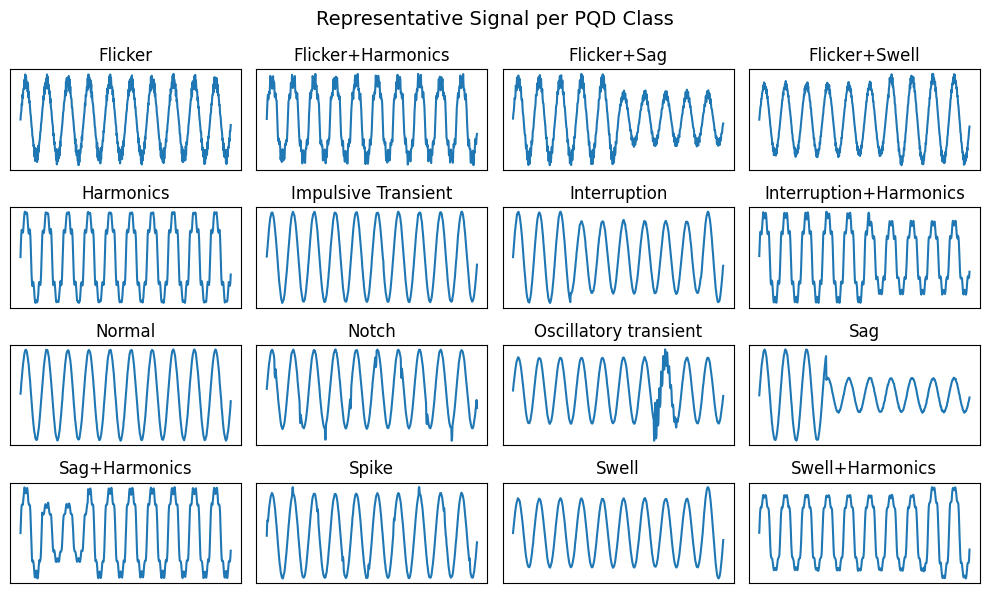

In [7]:
unique_classes = np.unique(Y)

plt.figure(figsize=(10, 6))

for i, class_name in enumerate(unique_classes[:16]):
    idx = np.where(Y == class_name)[0][0]

    plt.subplot(4, 4, i + 1)
    plt.plot(X[idx])
    plt.title(str(class_name))
    plt.xticks([])
    plt.yticks([])

plt.suptitle("Representative Signal per PQD Class", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Signal Transformation and Feature Extraction

Multilevel DWT decomposes each signal into appromation and detail coefficients.\
Where approximation coefficients capture lower-frequency behavior\
And detail coefficients capture higher-frequency behavior

In [8]:
signal_index = 7
signal = X[signal_index]

wavelet = "db4"
level = 4

coeffs = pywt.wavedec(signal, wavelet=wavelet, level=level)

print("Number of coefficient groups:", len(coeffs))
for i, c in enumerate(coeffs):
    print(f"Coefficient group {i}: shape = {c.shape}")

Number of coefficient groups: 5
Coefficient group 0: shape = (39,)
Coefficient group 1: shape = (39,)
Coefficient group 2: shape = (72,)
Coefficient group 3: shape = (138,)
Coefficient group 4: shape = (270,)


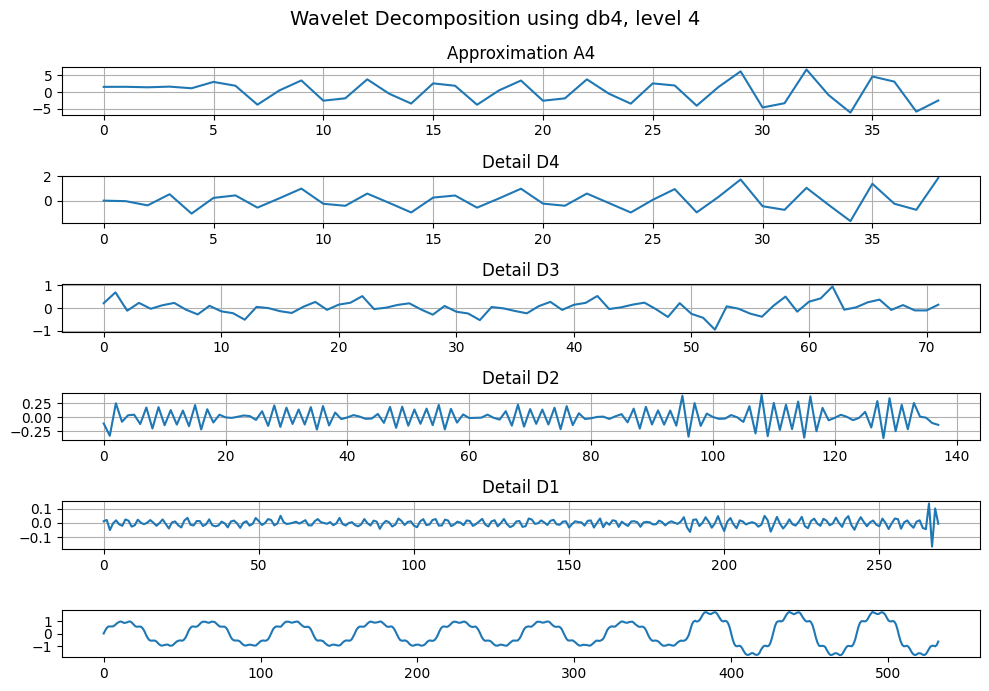

In [9]:
plt.figure(figsize=(10, 7))

titles = ["Approximation A4", "Detail D4", "Detail D3", "Detail D2", "Detail D1"]

for i, coeff in enumerate(coeffs):
    plt.subplot(len(coeffs) + 1, 1, i + 1)
    plt.plot(coeff)
    plt.title(titles[i] if i < len(titles) else f"Coeff {i}")
    plt.grid(True)

plt.subplot(6, 1, 6)
plt.plot(X[signal_index])
plt.suptitle(f"Wavelet Decomposition using {wavelet}, level {level}", fontsize=14)
plt.tight_layout()
plt.show()

Feature extraction is done with Statistical Wavelet Features\
For each wavelet coefficient group, it extracts: Mean, Standard deviation, Energy, RMS, Maximum, Minimum, Skew and Kurtosis.\
Therefore, with 5 coefficient group, there are 8 statistics = 40 features per signal

In [10]:
def extract_wavelet_stat_features(signal, wavelet="db4", level=4):
    coeffs = pywt.wavedec(signal, wavelet=wavelet, level=level)

    features = []

    for coeff in coeffs:
        coeff = np.asarray(coeff)

        mean = np.mean(coeff)
        std = np.std(coeff)
        energy = np.sum(coeff ** 2)
        rms = np.sqrt(np.mean(coeff ** 2))
        maximum = np.max(coeff)
        minimum = np.min(coeff)
        coeff_skew = skew(coeff)
        coeff_kurtosis = kurtosis(coeff)

        features.extend([
            mean,
            std,
            energy,
            rms,
            maximum,
            minimum,
            coeff_skew,
            coeff_kurtosis
        ])

    return np.array(features)

Extract statistical wavelet features for all signals

In [11]:
start_feature = time.time()

X_wavelet_stats = np.array([
    extract_wavelet_stat_features(signal, wavelet="db4", level=4)
    for signal in X
])

end_feature = time.time()
feature_time = end_feature - start_feature

print("Original X shape:", X.shape)
print("Wavelet statistical feature shape:", X_wavelet_stats.shape)
print(f"Feature extraction time: {feature_time:.4f} seconds")

Original X shape: (32000, 533)
Wavelet statistical feature shape: (32000, 40)
Feature extraction time: 106.5249 seconds


Split for training and testing, it uses a scikit learn function that randomizes element selection.

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_wavelet_stats,
    Y_encoded,
    test_size=TEST_PERCENTAGE,
    random_state=42,
    stratify=Y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", Y_train.shape)
print("y_test:", Y_test.shape)

X_train: (28800, 40)
X_test: (3200, 40)
y_train: (28800,)
y_test: (3200,)


## 3. Create, Train and Test SVM model

```kernel="rbf"``` Creates a non-linear decision boundary by mapping samples into a higher-dimensional space using a bell-shaped Gaussian curve function\
```C=10``` Sets a strong regularization penalty; it forces the model to strictly minimize training errors, which increases model complexity and risks overfitting compared to the default value of 1.0\
```gamma="scale"``` Automatically computes the kernel coefficient using _(1 / (n_features * X.var()))_, adapting the radius of influence based on your input features' variance and count\
```decision_function_shape="ovo"``` Uses the One-vs-One multi-class strategy (training n(n-1)/2 binary classifiers for n classes), default is "ovr" (One-vs-Rest).

In [13]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        decision_function_shape="ovo"
    ))
])

In [14]:
start_train = time.time()

svm_pipeline.fit(X_train, Y_train)

end_train = time.time()
training_time = end_train - start_train

print(f"Training time: {training_time:.4f} seconds")

Training time: 4.4955 seconds


In [15]:
start_test = time.time()

Y_pred = svm_pipeline.predict(X_test)

end_test = time.time()
testing_time = end_test - start_test

print(f"Testing time: {testing_time:.4f} seconds")

Testing time: 2.9769 seconds


In [16]:
accuracy = accuracy_score(Y_test, Y_pred)
macro_f1 = f1_score(Y_test, Y_pred, average="macro")
weighted_f1 = f1_score(Y_test, Y_pred, average="weighted")

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}")
print(f"Weighted F1-score: {weighted_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    Y_test,
    Y_pred,
    target_names=class_names
))

Accuracy: 0.8441
Macro F1-score: 0.8438
Weighted F1-score: 0.8437

Classification Report:
                        precision    recall  f1-score   support

               Flicker       0.94      0.98      0.96       199
     Flicker+Harmonics       0.99      0.98      0.99       200
           Flicker+Sag       0.98      0.91      0.94       201
         Flicker+Swell       0.99      0.94      0.96       198
             Harmonics       0.95      1.00      0.98       200
   Impulsive Transient       0.92      0.86      0.89       202
          Interruption       0.55      0.53      0.54       199
Interruption+Harmonics       0.48      0.53      0.50       201
                Normal       0.76      1.00      0.86       201
                 Notch       0.99      0.94      0.97       200
 Oscillatory transient       1.00      0.96      0.98       199
                   Sag       0.54      0.55      0.54       200
         Sag+Harmonics       0.47      0.41      0.44       200
             

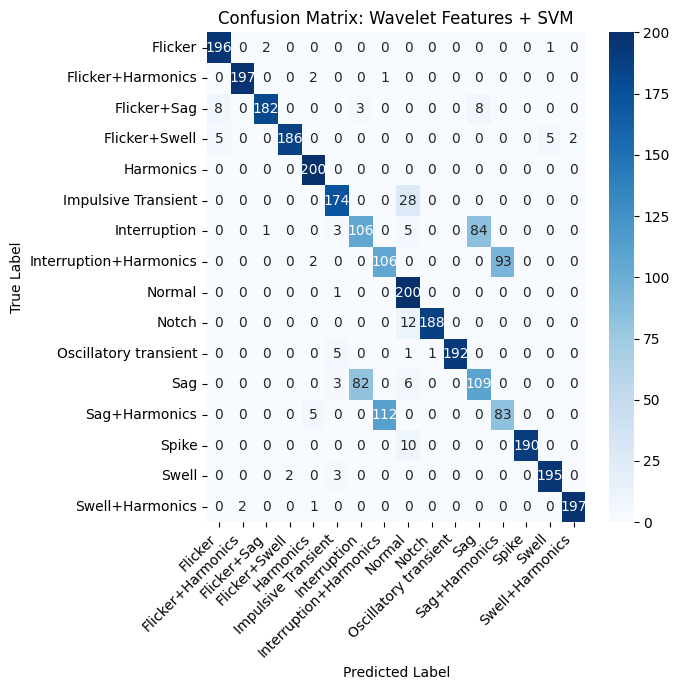

In [17]:
cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(7, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Wavelet Features + SVM")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Hyperparameter Tuning

This searches for stronger SVM parameters using macro F1-score

In [18]:
param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.01, 0.001, 0.0001],
    "svm__kernel": ["rbf"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

start_grid = time.time()

grid_search.fit(X_train, Y_train)

end_grid = time.time()
grid_time = end_grid - start_grid

print("Best parameters:", grid_search.best_params_)
print("Best CV macro F1:", grid_search.best_score_)
print(f"Grid search time: {grid_time:.4f} seconds")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Best CV macro F1: 0.8453809342572504
Grid search time: 377.0287 seconds


In [19]:
best_svm = grid_search.best_estimator_

start_test = time.time()
y_pred_best = best_svm.predict(X_test)
end_test = time.time()

best_accuracy = accuracy_score(Y_test, y_pred_best)
best_macro_f1 = f1_score(Y_test, y_pred_best, average="macro")
best_testing_time = end_test - start_test

print("Best SVM test accuracy:", best_accuracy)
print("Best SVM test macro F1:", best_macro_f1)
print("Best SVM testing time:", best_testing_time)

print(classification_report(
    Y_test,
    y_pred_best,
    target_names=class_names
))

Best SVM test accuracy: 0.8490625
Best SVM test macro F1: 0.848969389136418
Best SVM testing time: 2.1598868370056152
                        precision    recall  f1-score   support

               Flicker       0.95      0.99      0.97       199
     Flicker+Harmonics       0.99      0.99      0.99       200
           Flicker+Sag       0.98      0.93      0.96       201
         Flicker+Swell       0.99      0.95      0.97       198
             Harmonics       0.97      1.00      0.98       200
   Impulsive Transient       0.94      0.87      0.90       202
          Interruption       0.56      0.53      0.54       199
Interruption+Harmonics       0.49      0.52      0.50       201
                Normal       0.78      1.00      0.87       201
                 Notch       0.99      0.94      0.97       200
 Oscillatory transient       0.99      0.97      0.98       199
                   Sag       0.54      0.55      0.54       200
         Sag+Harmonics       0.48      0.43      

## 5. Compare Different Wavelets and Decompossition Levels

In [42]:
wavelets = ["haar", "db4", "sym4", "coif1"]
levels = [2, 3, 4, 5]

results = []

for wavelet in wavelets:
    for level in levels:
        print(f"Testing wavelet={wavelet}, level={level}")

        try:
            X_features = np.array([
                extract_wavelet_stat_features(signal, wavelet=wavelet, level=level)
                for signal in X
            ])

            X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
                X_features,
                Y_encoded,
                test_size=SPLIT_PERCENTAGE,
                random_state=42,
                stratify=Y_encoded
            )

            model = Pipeline([
                ("scaler", StandardScaler()),
                ("svm", SVC(kernel="rbf", C=10, gamma="scale"))
            ])

            start_train = time.time()
            model.fit(X_train_w, y_train_w)
            end_train = time.time()

            start_test = time.time()
            y_pred_w = model.predict(X_test_w)
            end_test = time.time()

            acc = accuracy_score(y_test_w, y_pred_w)
            f1 = f1_score(y_test_w, y_pred_w, average="macro")

            results.append({
                "wavelet": wavelet,
                "level": level,
                "accuracy": acc,
                "macro_f1": f1,
                "training_time": end_train - start_train,
                "testing_time": end_test - start_test,
                "n_features": X_features.shape[1]
            })

        except Exception as e:
            print(f"Failed for wavelet={wavelet}, level={level}: {e}")

results_df = pd.DataFrame(results)
results_df.sort_values(by="macro_f1", ascending=False)

Testing wavelet=haar, level=2
Testing wavelet=haar, level=3
Testing wavelet=haar, level=4
Testing wavelet=haar, level=5
Testing wavelet=db4, level=2
Testing wavelet=db4, level=3
Testing wavelet=db4, level=4
Testing wavelet=db4, level=5
Testing wavelet=sym4, level=2
Testing wavelet=sym4, level=3
Testing wavelet=sym4, level=4
Testing wavelet=sym4, level=5
Testing wavelet=coif1, level=2
Testing wavelet=coif1, level=3
Testing wavelet=coif1, level=4
Testing wavelet=coif1, level=5


NameError: name 'pd' is not defined

In [44]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="macro_f1", ascending=False)

,wavelet,level,accuracy,macro_f1,training_time,testing_time,n_features
4,db4,2,0.771557,0.764469,0.040362,0.571555,24
15,coif1,5,0.762876,0.760485,0.040372,0.599765,48
6,db4,4,0.766782,0.759340,0.024675,0.701342,40
9,sym4,3,0.766493,0.759282,0.054351,0.673604,32
5,db4,3,0.766638,0.758948,0.044963,0.473028,32
7,db4,5,0.763166,0.757547,0.053744,0.806880,48
14,coif1,4,0.760127,0.755990,0.024884,0.655219,40
13,coif1,3,0.758391,0.753340,0.047278,0.557157,32
12,coif1,2,0.757378,0.753259,0.049917,0.645391,24
8,sym4,2,0.758970,0.752533,0.025544,0.391530,24


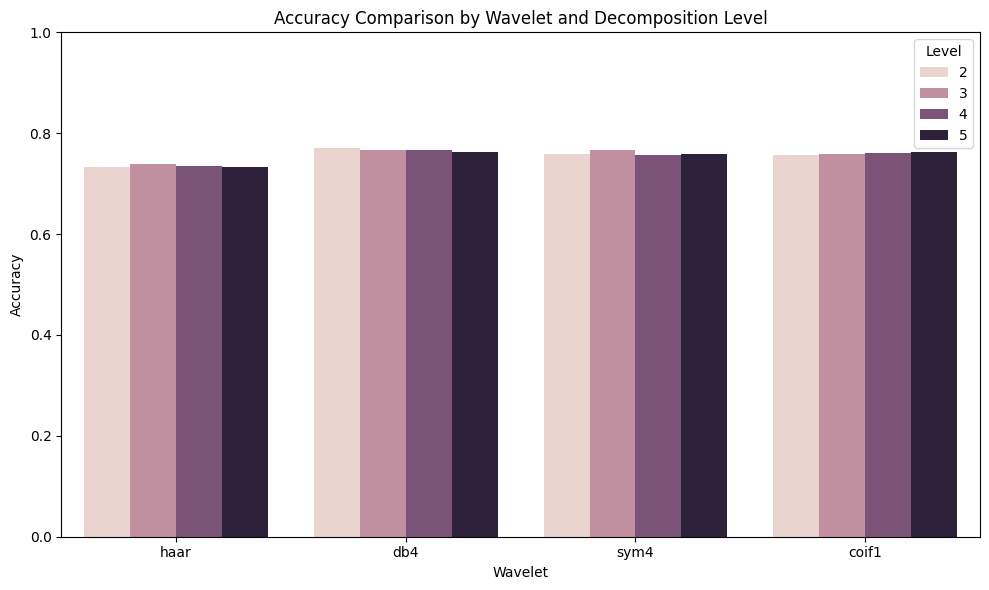

In [45]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="wavelet",
    y="accuracy",
    hue="level"
)

plt.title("Accuracy Comparison by Wavelet and Decomposition Level")
plt.xlabel("Wavelet")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend(title="Level")
plt.tight_layout()
plt.show()

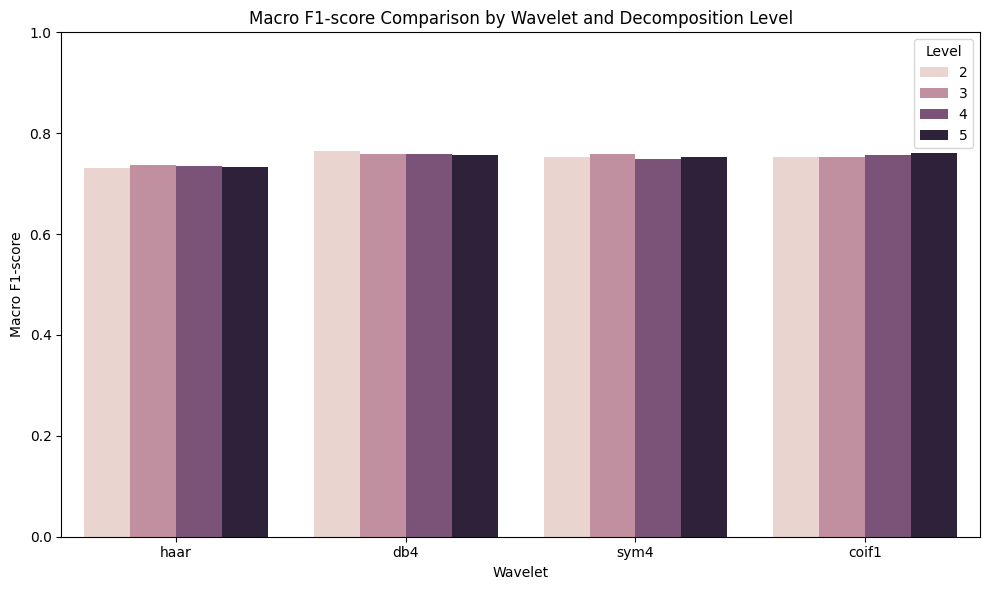

In [46]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="wavelet",
    y="macro_f1",
    hue="level"
)

plt.title("Macro F1-score Comparison by Wavelet and Decomposition Level")
plt.xlabel("Wavelet")
plt.ylabel("Macro F1-score")
plt.ylim(0, 1)
plt.legend(title="Level")
plt.tight_layout()
plt.show()